# model 학습
| 모델                                   | 특징                          | 추천 이유                        |
| ------------------------------------ | --------------------------- | ---------------------------- |
| **Random Forest**                    | 비선형 분류 + Feature Importance | 샘플 수 적정, 해석 가능, 과적합에 강함      |
| **XGBoost**                          | 비선형, 성능 최적화, 불균형 대응         | 가중치 조절, 고성능, SHAP 분석 가능      |
| **SVC (RBF 커널)**                     | 비선형 경계 학습                   | t-SNE/UMAP 분포에서 효과적          |
| **Logistic Regression (ElasticNet)** | 선형 + 해석 가능                  | 해석력 우선시 시도 (PLS/PCA에서 분리될 때) |
| **K-Nearest Neighbors (KNN)**        | 지역기반 비선형                    | UMAP에서 국지적 패턴 분명할 때 유용       |


## ===============================

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 경로 설정
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl"

# 1. 변화율 Top 10 feature 데이터 불러오기
top10_data_path = os.path.join(save_dir, "all_top10_data.pkl")
with open(top10_data_path, 'rb') as f:
    all_top10_data = pickle.load(f)

# 2. 변화율 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
with open(change_analysis_path, 'rb') as f:
    change_analysis_results = pickle.load(f)

## 1. TPC 먼저 모델 학습

In [2]:
# 3. TPC 라벨 생성 및 데이터 준비

# TPC 최적 임계값 설정
TPC_THR_LOW = 3.927 
TPC_THR_HIGH = 5.368

# 라벨 생성 함수
def create_tpc_labels(df, tpc_col='TPC (log CFU/g)', 
                      tpc_low=TPC_THR_LOW, tpc_high=TPC_THR_HIGH):
    """TPC 값을 기준으로 라벨 생성"""
    conditions = [
        df[tpc_col] < tpc_low,      # Fresh
        df[tpc_col] >= tpc_high,    # Decay
    ]
    choices = [0, 1]  # Fresh=0, Decay=1
    labels = np.select(conditions, choices, default=2)  # Middle=2
    return labels

# 라벨명 매핑
LABEL_NAMES = {0: 'Fresh', 1: 'Decay', 2: 'Middle'}
LABEL_COLORS = {0: 'green', 1: 'red', 2: 'orange'}

# 4. 모든 taxonomy level에 라벨 추가 (Top 10 feature만 사용)
final_taxonomic_levels_with_label = []

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    top10_df = all_top10_data[level_name]['top10_data'].copy()
    # 라벨 생성
    top10_df['Label'] = create_tpc_labels(top10_df)
    # Day 컬럼 추가
    top10_df['Day'] = top10_df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    final_taxonomic_levels_with_label.append((level_name, top10_df))

    print(f"\n=== {level_name} Level ===")
    print(f"Shape: {top10_df.shape}")
    feature_cols = all_top10_data[level_name]['top_10_feature_names']
    print(f"미생물 Feature 수: {len(feature_cols)}")
    label_counts = np.bincount(top10_df['Label'])
    total = len(top10_df)
    for i, count in enumerate(label_counts):
        name = LABEL_NAMES[i]
        percentage = count / total * 100
        print(f"{name}: {count}개 ({percentage:.1f}%)")

print(f"\n=== 라벨 생성 완료 ===")
print(f"임계값: Fresh < {TPC_THR_LOW}, Decay ≥ {TPC_THR_HIGH}")


=== Phylum Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Class Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Order Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Family Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Genus Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== 라벨 생성 완료 ===
임계값: Fresh < 3.927, Decay ≥ 5.368


## GridSearch CV 결과

=== Fresh + Middle 데이터 회귀 모델 학습 (Genus Level) ===
전체 데이터: 270개
Fresh + Middle 데이터: 181개
Feature 수: 10
Target 범위: 2.062 ~ 5.230
Train set: 144개
Test set: 37개

--- LightGBM 학습 중 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Test MAE: 0.2404
Test RMSE: 0.3067
Test R2: 0.5100

--- RandomForest 학습 중 ---
Best Params: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 300}
Test MAE: 0.2342
Test RMSE: 0.2997
Test R2: 0.5322

--- XGBoost 학습 중 ---
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Test MAE: 0.2579
Test RMSE: 0.3202
Test R2: 0.4659

--- SVR 학습 중 ---
Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Test MAE: 0.2499
Test RMSE: 0.3015
Test R2: 0.5265

=== Fresh + Middle 회귀 모델 성능 결과 (Genus Level) ===
  Taxonomy_Level         Model  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE  \
0          Genus      LightGBM   0.249923  0.240362    0.325968   0.306700   
1          Genus  RandomForest   0.252324  0.234237    0.321623   0.299693   
2          Genus       XGBoost   0.235745  0.257921    0.303563   0.320213   
3          Genus           SVR   0.268141  0.249892    0.371500   0.301513   

  

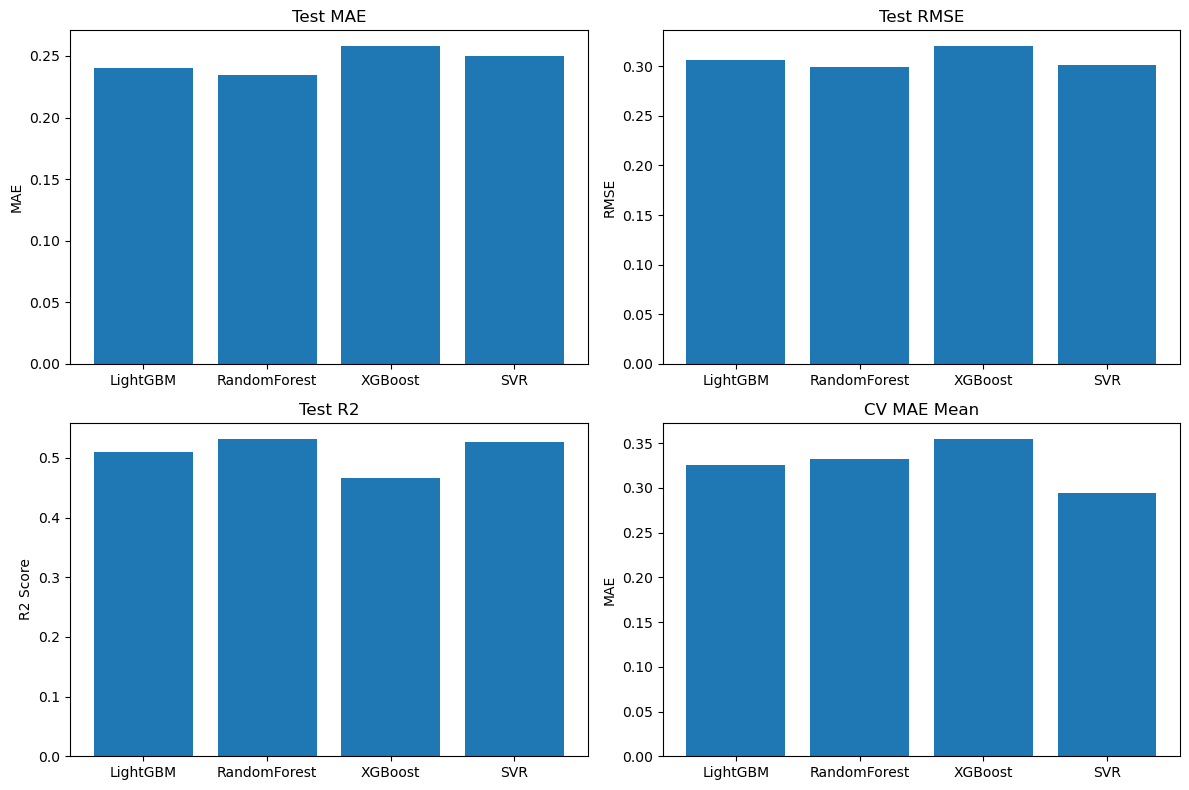

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import os

# Fresh + Middle 데이터 회귀 모델 학습 (Genus Level만)
print("=== Fresh + Middle 데이터 회귀 모델 학습 (Genus Level) ===")

# Genus level 데이터 가져오기
genus_level_data = None
for level_name, df in final_taxonomic_levels_with_label:
    if level_name == 'Genus':
        genus_level_data = df.copy()
        break

if genus_level_data is None:
    print("Genus level 데이터를 찾을 수 없습니다.")
else:
    # Fresh (0)와 Middle (2) 데이터만 선택
    fresh_middle_data = genus_level_data[genus_level_data['Label'].isin([0, 2])].copy()
    
    print(f"전체 데이터: {len(genus_level_data)}개")
    print(f"Fresh + Middle 데이터: {len(fresh_middle_data)}개")
    
    # Feature와 Target 분리
    feature_cols = all_top10_data['Genus']['top_10_feature_names']
    X = fresh_middle_data[feature_cols].values
    y = fresh_middle_data['TPC (log CFU/g)'].values
    
    print(f"Feature 수: {len(feature_cols)}")
    print(f"Target 범위: {y.min():.3f} ~ {y.max():.3f}")
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=fresh_middle_data['Label']
    )
    
    print(f"Train set: {X_train.shape[0]}개")
    print(f"Test set: {X_test.shape[0]}개")
    
    # 모델 설정
    models = {
        'LightGBM': {
            'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2]
            }
        },
        'RandomForest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7, None],
                'min_samples_split': [2, 5, 10]
            }
        },
        'XGBoost': {
            'model': xgb.XGBRegressor(random_state=42, verbosity=0),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2]
            }
        },
        'SVR': {
            'model': SVR(),
            'params': {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01],
                'kernel': ['rbf', 'linear']
            }
        }
    }
    
    # 성능 평가 함수
    def calculate_metrics(y_true, y_pred, prefix=""):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        rsd = (rmse / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 0
        
        return {
            f"{prefix}MAE": mae,
            f"{prefix}RMSE": rmse,
            f"{prefix}R2": r2,
            f"{prefix}RSD": rsd
        }
    
    # 모델 학습 및 평가
    results = []
    
    for model_name, model_config in models.items():
        print(f"\n--- {model_name} 학습 중 ---")
        
        # GridSearchCV
        grid = GridSearchCV(
            model_config['model'], 
            model_config['params'], 
            cv=5, 
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        # 예측
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        # Cross Validation
        cv_mae = -cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
        cv_rmse = np.sqrt(-cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
        cv_r2 = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
        
        # 성능 계산
        train_metrics = calculate_metrics(y_train, y_train_pred, "Train_")
        test_metrics = calculate_metrics(y_test, y_test_pred, "Test_")
        
        # Overfitting 지표
        overfit_mae = train_metrics["Train_MAE"] - test_metrics["Test_MAE"]
        overfit_rmse = train_metrics["Train_RMSE"] - test_metrics["Test_RMSE"]
        overfit_r2 = train_metrics["Train_R2"] - test_metrics["Test_R2"]
        overfit_rsd = train_metrics["Train_RSD"] - test_metrics["Test_RSD"]
        
        # 결과 저장
        result = {
            "Taxonomy_Level": "Genus",
            "Model": model_name,
            "Train_MAE": train_metrics["Train_MAE"],
            "Test_MAE": test_metrics["Test_MAE"],
            "Train_RMSE": train_metrics["Train_RMSE"],
            "Test_RMSE": test_metrics["Test_RMSE"],
            "Train_R2": train_metrics["Train_R2"],
            "Test_R2": test_metrics["Test_R2"],
            "Train_RSD": train_metrics["Train_RSD"],
            "Test_RSD": test_metrics["Test_RSD"],
            "Overfit_MAE": overfit_mae,
            "Overfit_RMSE": overfit_rmse,
            "Overfit_R2": overfit_r2,
            "Overfit_RSD": overfit_rsd,
            "CV_MAE_Mean": cv_mae.mean(),
            "CV_RMSE_Mean": cv_rmse.mean(),
            "CV_R2_Mean": cv_r2.mean(),
            "Best_Params": str(grid.best_params_)
        }
        
        results.append(result)
        
        print(f"Best Params: {grid.best_params_}")
        print(f"Test MAE: {test_metrics['Test_MAE']:.4f}")
        print(f"Test RMSE: {test_metrics['Test_RMSE']:.4f}")
        print(f"Test R2: {test_metrics['Test_R2']:.4f}")
    
    # 결과 DataFrame 생성 및 출력
    results_df = pd.DataFrame(results)
    
    print("\n=== Fresh + Middle 회귀 모델 성능 결과 (Genus Level) ===")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(results_df)
    
    # 결과 저장
    os.makedirs("model_result", exist_ok=True)
    results_df.to_excel("model_result/fresh_middle_regression_results_genus.xlsx", index=False)
    print(f"\n결과가 'model_result/fresh_middle_regression_results_genus.xlsx'에 저장되었습니다.")
    
    # 간단한 성능 비교 시각화
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Test MAE
    axes[0,0].bar(results_df['Model'], results_df['Test_MAE'])
    axes[0,0].set_title('Test MAE')
    axes[0,0].set_ylabel('MAE')
    
    # Test RMSE
    axes[0,1].bar(results_df['Model'], results_df['Test_RMSE'])
    axes[0,1].set_title('Test RMSE')
    axes[0,1].set_ylabel('RMSE')
    
    # Test R2
    axes[1,0].bar(results_df['Model'], results_df['Test_R2'])
    axes[1,0].set_title('Test R2')
    axes[1,0].set_ylabel('R2 Score')
    
    # CV MAE Mean
    axes[1,1].bar(results_df['Model'], results_df['CV_MAE_Mean'])
    axes[1,1].set_title('CV MAE Mean')
    axes[1,1].set_ylabel('MAE')
    
    plt.tight_layout()
    plt.show()

In [4]:
# 결과 저장 - CLR_KMenas_변화_TPC 파일명으로 저장
os.makedirs("model_result", exist_ok=True)
results_df.to_excel("model_result/CLR_KMenas_변화_TPC.xlsx", index=False)
print(f"\n결과가 'model_result/CLR_KMenas_변화_TPC.xlsx'에 저장되었습니다.")

# 추가적인 상세 정보도 함께 저장
with pd.ExcelWriter("model_result/CLR_KMenas_변화_TPC_상세.xlsx") as writer:
    # 모델 성능 결과
    results_df.to_excel(writer, sheet_name='모델성능', index=False)
    
    # 데이터 정보
    data_info = pd.DataFrame({
        'Info': ['전체 데이터 수', 'Fresh+Middle 데이터 수', 'Feature 수', 'Train 데이터 수', 'Test 데이터 수', 'Target 최소값', 'Target 최대값'],
        'Value': [len(genus_level_data), len(fresh_middle_data), len(feature_cols), X_train.shape[0], X_test.shape[0], y.min(), y.max()]
    })
    data_info.to_excel(writer, sheet_name='데이터정보', index=False)
    
    # Feature 이름
    feature_info = pd.DataFrame({'Feature_Names': feature_cols})
    feature_info.to_excel(writer, sheet_name='Feature목록', index=False)

print(f"상세 결과가 'model_result/CLR_KMenas_변화_TPC_상세.xlsx'에 저장되었습니다.")


결과가 'model_result/CLR_KMenas_변화_TPC.xlsx'에 저장되었습니다.
상세 결과가 'model_result/CLR_KMenas_변화_TPC_상세.xlsx'에 저장되었습니다.


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

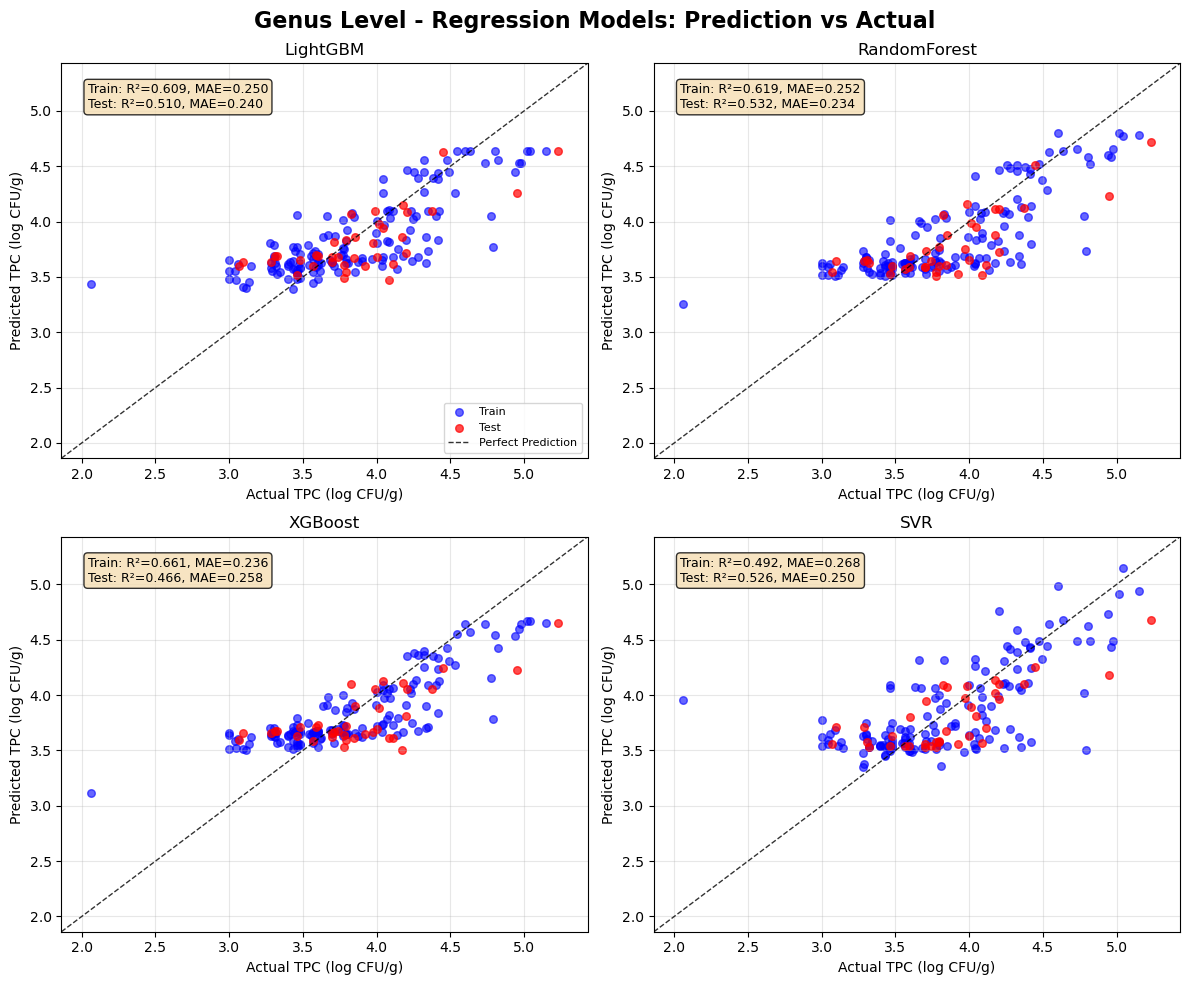

In [5]:
# Prediction vs Actual 시각화 (기존 결과 활용)
import matplotlib.pyplot as plt
import numpy as np

# 각 모델별로 다시 예측 (시각화용으로만)
model_predictions = {}

for model_name, model_config in models.items():
    # GridSearch로 최적 모델 찾기
    grid = GridSearchCV(
        model_config['model'], 
        model_config['params'], 
        cv=5, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    
    # 예측
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # 성능 계산
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    model_predictions[model_name] = {
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae
    }

# 2x2 subplot 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Genus Level - Regression Models: Prediction vs Actual', fontsize=16, fontweight='bold')

model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR']
min_val = min(y_train.min(), y_test.min()) - 0.2
max_val = max(y_train.max(), y_test.max()) + 0.2

for i, model_name in enumerate(model_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    pred_data = model_predictions[model_name]
    
    # Train 데이터 (파란색)
    ax.scatter(y_train, pred_data['y_train_pred'], 
               alpha=0.6, color='blue', s=30, label='Train')
    
    # Test 데이터 (빨간색)
    ax.scatter(y_test, pred_data['y_test_pred'], 
               alpha=0.7, color='red', s=30, label='Test')
    
    # Perfect prediction line
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k--', alpha=0.8, linewidth=1, label='Perfect Prediction')
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel('Actual TPC (log CFU/g)')
    ax.set_ylabel('Predicted TPC (log CFU/g)')
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)
    
    # 성능 지표 텍스트
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)
    
    if i == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

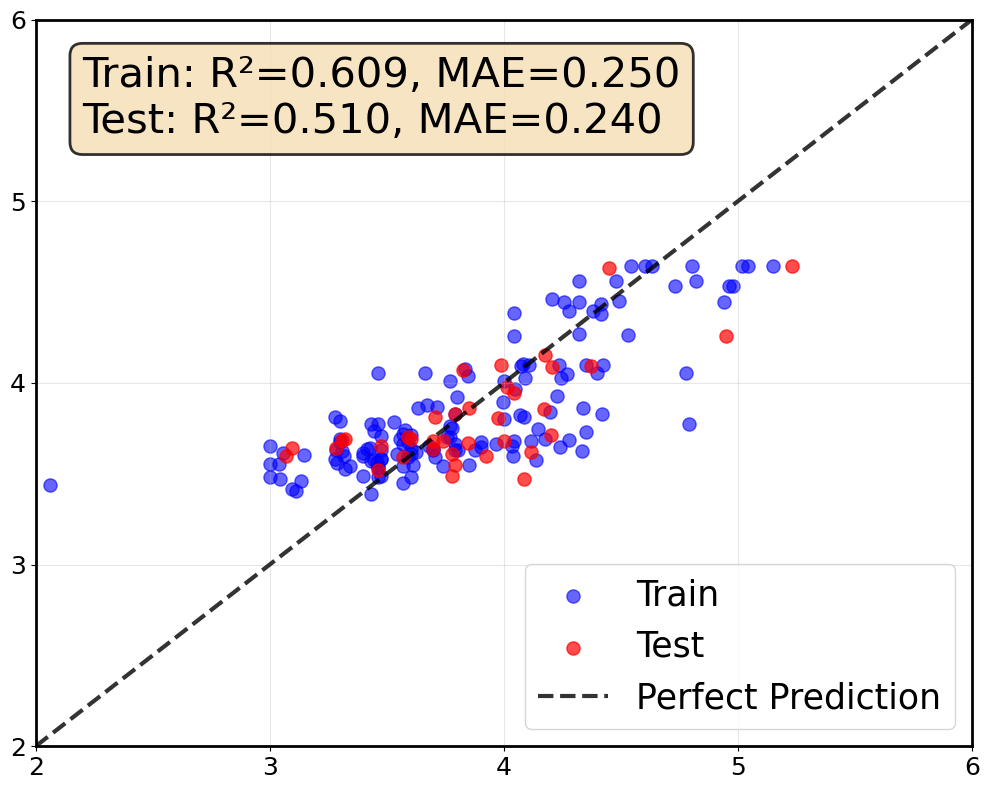

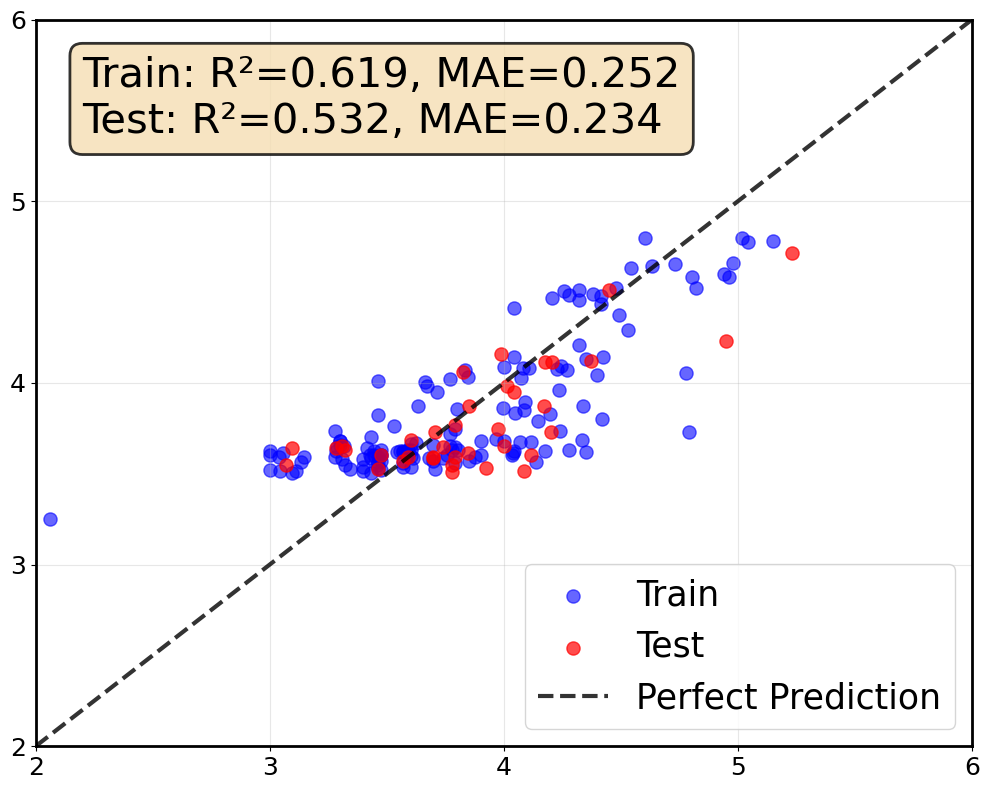

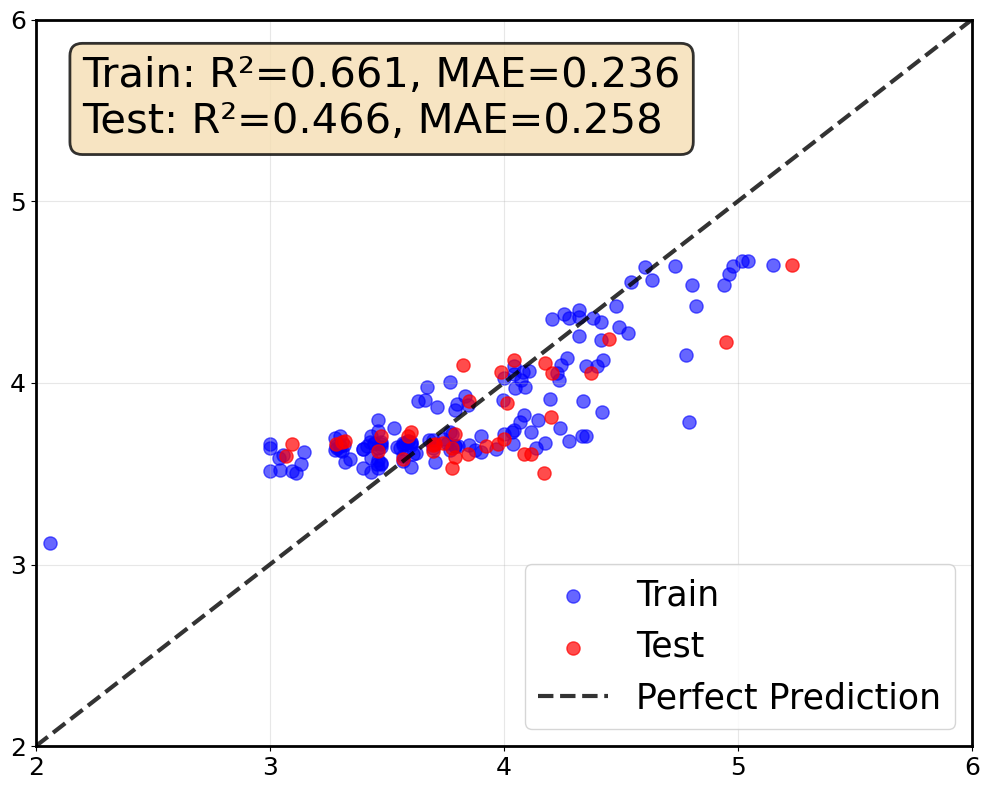

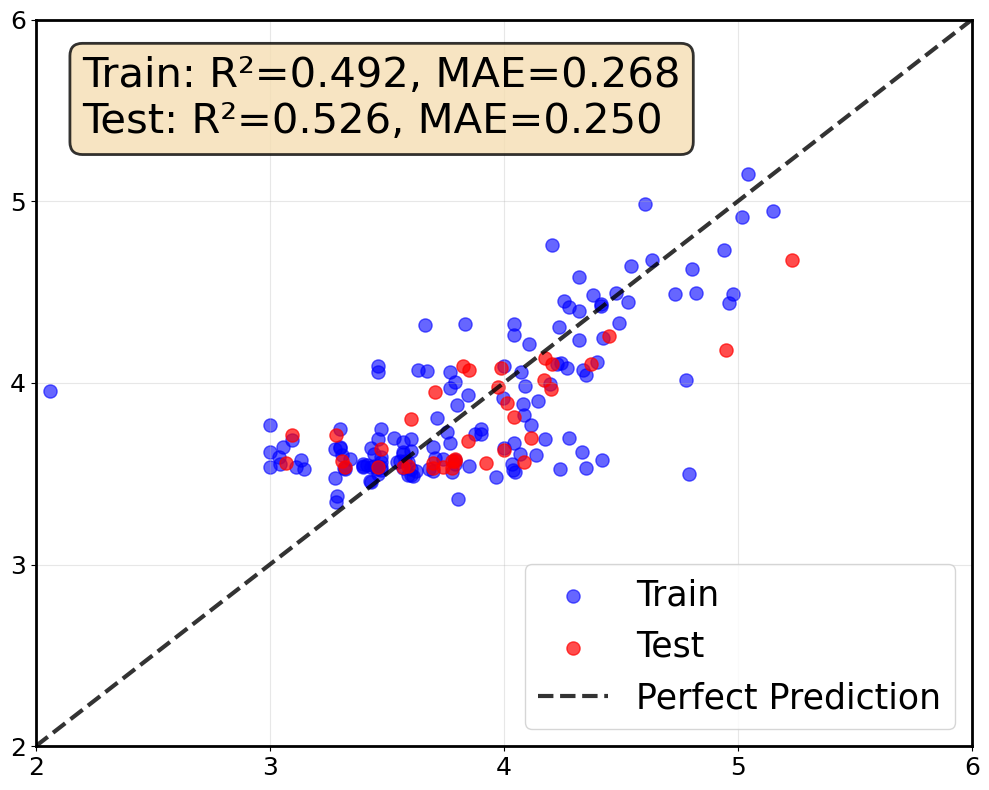

In [6]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR']
colors = {'Train': 'blue', 'Test': 'red'}

min_val = 2
max_val = 6
ticks = [2, 3, 4, 5, 6]

for model_name in model_names:
    pred_data = model_predictions[model_name]
    fig, ax = plt.subplots(figsize=(10, 8))

    # Train 데이터
    ax.scatter(y_train, pred_data['y_train_pred'],
               alpha=0.6, color=colors['Train'], label='Train', s=90)
    # Test 데이터
    ax.scatter(y_test, pred_data['y_test_pred'],
               alpha=0.7, color=colors['Test'], label='Test', s=90)
    # 완벽 예측선
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=3, label='Perfect Prediction')

    # 성능 텍스트 박스
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=30,
            verticalalignment='top', bbox=props)

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.legend(fontsize=25)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()